In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s5e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s5e8/train.csv
/kaggle/input/competitions/playground-series-s5e8/test.csv


In [16]:
data = pd.read_csv('/kaggle/input/competitions/playground-series-s5e8/train.csv')
data.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [17]:
data.drop('id',axis=1,inplace=True)

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   age        750000 non-null  int64 
 1   job        750000 non-null  object
 2   marital    750000 non-null  object
 3   education  750000 non-null  object
 4   default    750000 non-null  object
 5   balance    750000 non-null  int64 
 6   housing    750000 non-null  object
 7   loan       750000 non-null  object
 8   contact    750000 non-null  object
 9   day        750000 non-null  int64 
 10  month      750000 non-null  object
 11  duration   750000 non-null  int64 
 12  campaign   750000 non-null  int64 
 13  pdays      750000 non-null  int64 
 14  previous   750000 non-null  int64 
 15  poutcome   750000 non-null  object
 16  y          750000 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 97.3+ MB


In [19]:
from sklearn.preprocessing import LabelEncoder

cols_to_encode = ['default', 'housing','loan', 'education','month']  
le = LabelEncoder()

In [20]:
for col in cols_to_encode:
    data[col] = le.fit_transform(data[col])

In [21]:
data = pd.get_dummies(data, columns=['job','marital','contact','poutcome'])

In [37]:
data.head()

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,42,1,0,7,0,0,25,1,117,3,...,False,True,False,True,False,False,False,False,False,True
1,38,1,0,514,0,0,18,6,185,1,...,False,True,False,False,False,True,False,False,False,True
2,36,1,0,602,1,0,14,8,111,2,...,False,True,False,False,False,True,False,False,False,True
3,27,1,0,34,1,0,28,8,10,2,...,False,False,True,False,False,True,False,False,False,True
4,26,1,0,889,1,0,3,3,902,1,...,False,True,False,True,False,False,False,False,False,True


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

In [25]:
X = data.drop('y', axis=1)   
y = data['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [27]:
y_prob = rf.predict_proba(X_test)[:,1]  
y_pred = rf.predict(X_test)

In [28]:
acc = accuracy_score(y_test, y_pred)
acc

0.92966

In [29]:
roc_auc = roc_auc_score(y_test, y_prob)
roc_auc

np.float64(0.9602147247463595)

In [30]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[128115,   3787],
       [  6764,  11334]])

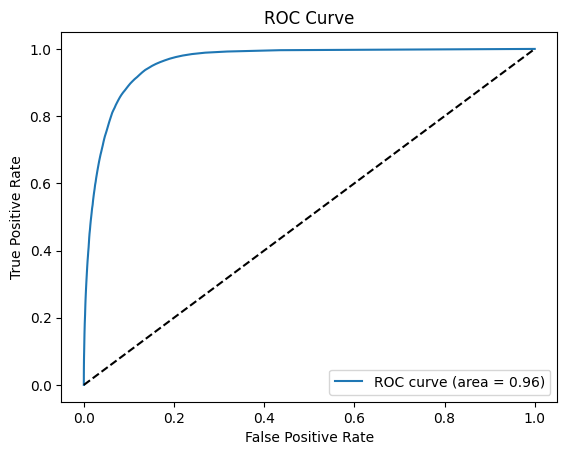

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [32]:
test = pd.read_csv('/kaggle/input/competitions/playground-series-s5e8/test.csv')
test.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


In [33]:
id_sum = test['id']
test.drop('id',axis=1,inplace=True)
for col in cols_to_encode:
    test[col] = le.fit_transform(test[col])
test = pd.get_dummies(test, columns=['job','marital','contact','poutcome'])

In [34]:
y_prob_sum = rf.predict_proba(test)[:,1]

In [36]:
submission = pd.DataFrame({
    'id': id_sum,
    'y': y_prob_sum
})

submission.to_csv("submission.csv",index=False)